<h1 align=center><font size = 5>Chicago Crime Analysis</font></h1>


# Introduction
## Project Overview

Every city faces different public safety challenges. Understanding where crimes occur, what types of crimes are most common, and whether socioeconomic conditions are associated with crime can help policymakers allocate resources more effectively.

In this project, I use SQL to analyze the Chicago Crime dataset together with community demographic and school information. The analysis focuses on identifying crime hotspots, examining crime around schools, and exploring community characteristics that may be associated with higher crime levels.

## Objectives

- Identify communities with the highest crime rates.
- Examine crimes occurring at schools.
- Explore relationships between crime and socioeconomic indicators.



## Datasets

Datasets use in this project:

### 1. Socioeconomic Indicators in Chicago

This dataset contains a selection of six socioeconomic indicators of public health significance and a “hardship index,” for each Chicago community area, for the years 2008 – 2012.

A detailed description of this dataset and the original dataset can be obtained from the Chicago Data Portal at:

[https://data.cityofchicago.org/Health-Human-Services/Census-Data-Selected-socioeconomic-indicators-in-C/kn9c-c2s2](https://data.cityofchicago.org/Health-Human-Services/Census-Data-Selected-socioeconomic-indicators-in-C/kn9c-c2s2?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkDB0201ENSkillsNetwork20127838-2021-01-01&cm_mmc=Email_Newsletter-\_-Developer_Ed%2BTech-\_-WW_WW-\_-SkillsNetwork-Courses-IBMDeveloperSkillsNetwork-DB0201EN-SkillsNetwork-20127838&cm_mmca1=000026UJ&cm_mmca2=10006555&cm_mmca3=M12345678&cvosrc=email.Newsletter.M12345678&cvo_campaign=000026UJ)

### 2. Chicago Public Schools

This dataset shows all school level performance data used to create CPS School Report Cards for the 2011-2012 school year. This dataset is provided by the city of Chicago's Data Portal.

A detailed description of this dataset and the original dataset can be obtained from the Chicago Data Portal at:

[https://data.cityofchicago.org/Education/Chicago-Public-Schools-Progress-Report-Cards-2011-/9xs2-f89t](https://data.cityofchicago.org/Education/Chicago-Public-Schools-Progress-Report-Cards-2011-/9xs2-f89t?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkDB0201ENSkillsNetwork20127838-2021-01-01&cm_mmc=Email_Newsletter-\_-Developer_Ed%2BTech-\_-WW_WW-\_-SkillsNetwork-Courses-IBMDeveloperSkillsNetwork-DB0201EN-SkillsNetwork-20127838&cm_mmca1=000026UJ&cm_mmca2=10006555&cm_mmca3=M12345678&cvosrc=email.Newsletter.M12345678&cvo_campaign=000026UJ)

### 3. Chicago Crime Data

This dataset reflects reported incidents of crime (with the exception of murders where data exists for each victim) that occurred in the City of Chicago from 2001 to present, minus the most recent seven days.

A detailed description of this dataset and the original dataset can be obtained from the Chicago Data Portal at:

[https://data.cityofchicago.org/Public-Safety/Crimes-2001-to-present/ijzp-q8t2](https://data.cityofchicago.org/Public-Safety/Crimes-2001-to-present/ijzp-q8t2?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkDB0201ENSkillsNetwork20127838-2021-01-01&cm_mmc=Email_Newsletter-\_-Developer_Ed%2BTech-\_-WW_WW-\_-SkillsNetwork-Courses-IBMDeveloperSkillsNetwork-DB0201EN-SkillsNetwork-20127838&cm_mmca1=000026UJ&cm_mmca2=10006555&cm_mmca3=M12345678&cvosrc=email.Newsletter.M12345678&cvo_campaign=000026UJ)


### Download the datasets



Use the links below to read the data files using the Pandas library. 

* Chicago Census Data

https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DB0201EN-SkillsNetwork/labs/FinalModule_Coursera_V5/data/ChicagoCensusData.csv?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkDB0201ENSkillsNetwork20127838-2021-01-01

* Chicago Public Schools

https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DB0201EN-SkillsNetwork/labs/FinalModule_Coursera_V5/data/ChicagoPublicSchools.csv?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkDB0201ENSkillsNetwork20127838-2021-01-01

* Chicago Crime Data

https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DB0201EN-SkillsNetwork/labs/FinalModule_Coursera_V5/data/ChicagoCrimeData.csv?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkDB0201ENSkillsNetwork20127838-2021-01-01

**NOTE:** Ensure you use the datasets available on the links above instead of directly from the Chicago Data Portal. The versions linked here are subsets of the original datasets and have some of the column names modified to be more database friendly which will make it easier to complete this assignment.


### Store the datasets in database tables

To analyze the data using SQL, it first needs to be loaded into SQLite DB.
We will create three tables in as under:

1.  **CHICAGO_CENSUS_DATA**
2.  **CHICAGO_PUBLIC_SCHOOLS_DATA**
3.  **CHICAGO_CRIME_DATA**


# Code

In [34]:
# Install, then import required ibraries
!pip install pandas
!pip install matplotlib
!pip install ipython-sql prettytable 

import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import prettytable

prettytable.DEFAULT = 'DEFAULT'

%load_ext sql

In [6]:
# Establish connection to FinalDB.db database
con = sqlite3.connect("FinalDB.db")
cur = con.cursor()

%sql sqlite:///FinalDB.db

In [8]:
# Load the datasets as tables to the database 

df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DB0201EN-SkillsNetwork/labs/FinalModule_Coursera_V5/data/ChicagoCensusData.csv?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkDB0201ENSkillsNetwork20127838-2021-01-01")
df.to_sql("CHICAGO_CENSUS_DATA", con, if_exists='replace', index=False, method="multi")

df2 = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DB0201EN-SkillsNetwork/labs/FinalModule_Coursera_V5/data/ChicagoPublicSchools.csv?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkDB0201ENSkillsNetwork20127838-2021-01-01")
df2.to_sql("CHICAGO_PUBLIC_SCHOOLS_DATA", con, if_exists="replace", index=False, method="multi")

df3 = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DB0201EN-SkillsNetwork/labs/FinalModule_Coursera_V5/data/ChicagoCrimeData.csv?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkDB0201ENSkillsNetwork20127838-2021-01-01")
df3.to_sql("CHICAGO_CRIME_DATA", con, if_exists="replace", index=False, method="multi")

533

## Business Questions

### A. Which Communities Experience the Most Crime

Questions:
- Which community has the highest number of crimes?
- What are the Top 10 communities by crime count?


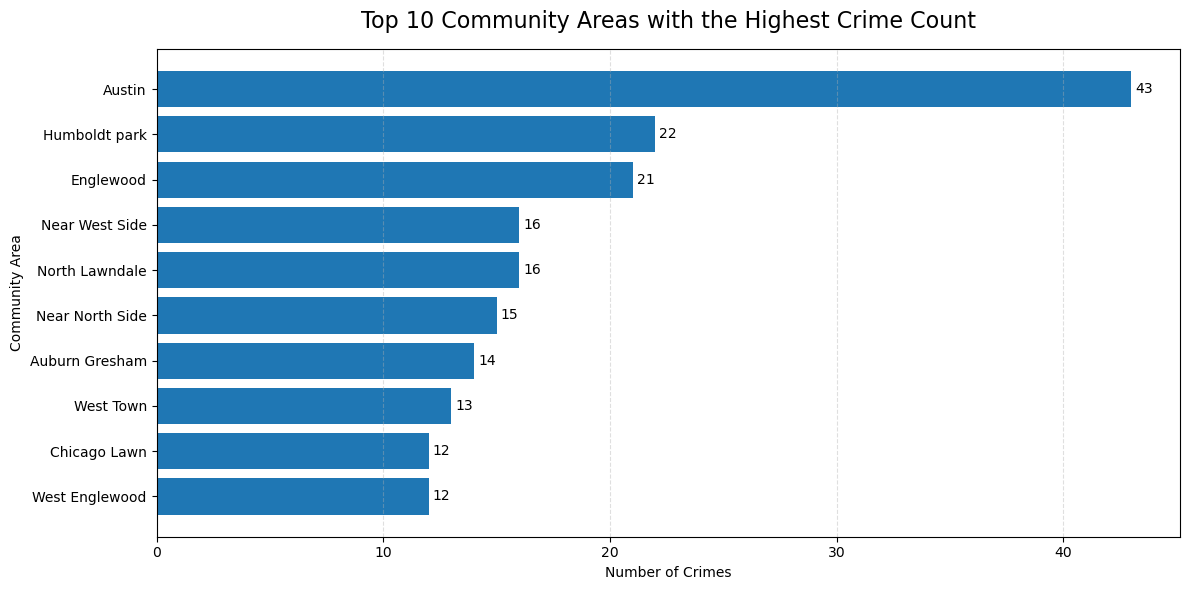

In [10]:
query = """
SELECT
    crime.community_area_number,
    census.community_area_name,
    COUNT(crime.community_area_number) AS Crime_Count
FROM chicago_crime_data AS crime
JOIN chicago_census_data AS census
    ON crime.community_area_number = census.community_area_number
GROUP BY
    crime.community_area_number,
    census.community_area_name
ORDER BY Crime_Count DESC
LIMIT 10;
"""

# Load SQL result into a DataFrame
df = pd.read_sql_query(query, con)


# Plot
plt.figure(figsize=(12, 6))

bars = plt.barh(df["COMMUNITY_AREA_NAME"], df["Crime_Count"])

plt.title("Top 10 Community Areas with the Highest Crime Count",
          fontsize=16,
          pad=15)

plt.xlabel("Number of Crimes")
plt.ylabel("Community Area")

plt.grid(axis="x", linestyle="--", alpha=0.4)

# Add the values at the end of each bar
plt.bar_label(bars, padding=3)

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

The bar chart above highlights the 10 Chicago communities with the highest crime counts. The following analysis explores whether socioeconomic indicators are associated with higher crime rates across these communities.

### B. Do Economic Conditions Relate to Crime

Question:
- Do Communities with lower income or higher hardship index tend to experience more crime?


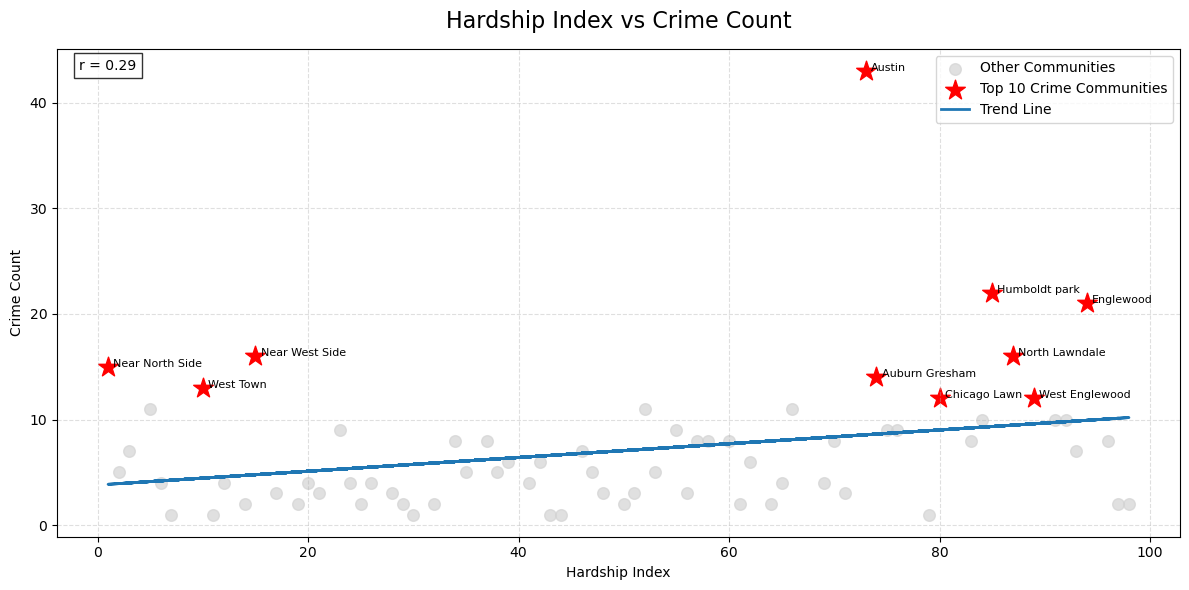

In [12]:
query = """
SELECT
    crime.community_area_number,
    census.community_area_name,
    census.hardship_index,
    COUNT(crime.community_area_number) AS Crime_Count
FROM chicago_crime_data AS crime
JOIN chicago_census_data AS census
    ON crime.community_area_number = census.community_area_number
GROUP BY
    crime.community_area_number,
    census.community_area_name,
    census.hardship_index
ORDER BY Crime_Count DESC;
"""

# Load SQL result into a DataFrame
df = pd.read_sql_query(query, con)

# Get the top 10 communities with the highest crime count
top10 = df.nlargest(10, "Crime_Count")["COMMUNITY_AREA_NAME"]

# Split the data
regular = df[~df["COMMUNITY_AREA_NAME"].isin(top10)]
highlight = df[df["COMMUNITY_AREA_NAME"].isin(top10)]

# Scatter Plot
plt.figure(figsize=(12, 6))

# All communities
plt.scatter(
    regular["HARDSHIP_INDEX"],
    regular["Crime_Count"],
    color="lightgray",
    s=70,
    alpha=0.7,
    label="Other Communities"
)

# Top 10 communities
plt.scatter(
    highlight["HARDSHIP_INDEX"],
    highlight["Crime_Count"],
    color="red",
    marker="*",
    s=220,
    label="Top 10 Crime Communities"
)

# Trend line (using ALL communities)
x = df["HARDSHIP_INDEX"]
y = df["Crime_Count"]

m, b = np.polyfit(x, y, 1)

plt.plot(
    x,
    m * x + b,
    linewidth=2,
    label="Trend Line"
)

plt.title("Hardship Index vs Crime Count", fontsize=16, pad=15)
plt.xlabel("Hardship Index")
plt.ylabel("Crime Count")

plt.grid(True, linestyle="--", alpha=0.4)

# Label only the highlighted communities
for _, row in highlight.iterrows():
    plt.text(
        row["HARDSHIP_INDEX"] + 0.5,
        row["Crime_Count"],
        row["COMMUNITY_AREA_NAME"],
        fontsize=8
    )

r = df["HARDSHIP_INDEX"].corr(df["Crime_Count"])

plt.text(
    0.02,
    0.98,
    f"r = {r:.2f}",
    transform=plt.gca().transAxes,
    verticalalignment="top",
    bbox=dict(facecolor="white", alpha=0.8)
)

plt.legend()

plt.tight_layout()
plt.show()

The correlation between Hardship Index and Crime Count is weak (r = 0.29), suggesting that communities with higher hardship tend to experience slightly more crime, but the relationship is not strong. Based on the coefficient of determination (r² = 0.0841), Hardship Index explains only about 8.4% of the variation in Crime Count, implying that many other factors contribute to differences in crime levels.

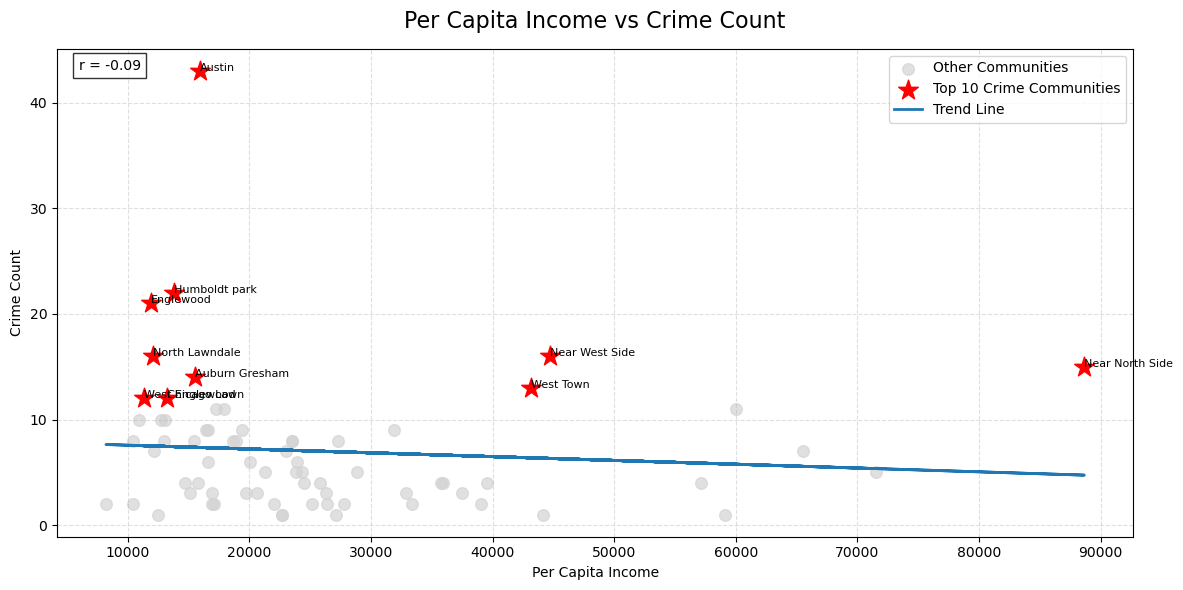

In [14]:
query = """
SELECT
    crime.community_area_number,
    census.community_area_name,
    census.per_capita_income,
    COUNT(crime.community_area_number) AS Crime_Count
FROM chicago_crime_data AS crime
JOIN chicago_census_data AS census
    ON crime.community_area_number = census.community_area_number
GROUP BY
    crime.community_area_number,
    census.community_area_name
ORDER BY Crime_Count DESC;
"""

# Load SQL result into a DataFrame
df = pd.read_sql_query(query, con)



# Get the top 10 communities with the highest crime count
top10 = df.nlargest(10, "Crime_Count")["COMMUNITY_AREA_NAME"]

# Split the data
regular = df[~df["COMMUNITY_AREA_NAME"].isin(top10)]
highlight = df[df["COMMUNITY_AREA_NAME"].isin(top10)]

# Scatter Plot
plt.figure(figsize=(12, 6))

# All communities
plt.scatter(
    regular["PER_CAPITA_INCOME"],
    regular["Crime_Count"],
    color="lightgray",
    s=70,
    alpha=0.7,
    label="Other Communities"
)

# Top 10 communities
plt.scatter(
    highlight["PER_CAPITA_INCOME"],
    highlight["Crime_Count"],
    color="red",
    marker="*",
    s=220,
    label="Top 10 Crime Communities"
)

# Trend line (using ALL communities)
x = df["PER_CAPITA_INCOME"]
y = df["Crime_Count"]

m, b = np.polyfit(x, y, 1)

plt.plot(
    x,
    m * x + b,
    linewidth=2,
    label="Trend Line"
)

plt.title("Per Capita Income vs Crime Count", fontsize=16, pad=15)
plt.xlabel("Per Capita Income")
plt.ylabel("Crime Count")

plt.grid(True, linestyle="--", alpha=0.4)

# Label only the highlighted communities
for _, row in highlight.iterrows():
    plt.text(
        row["PER_CAPITA_INCOME"] + 0.5,
        row["Crime_Count"],
        row["COMMUNITY_AREA_NAME"],
        fontsize=8
    )

r = df["PER_CAPITA_INCOME"].corr(df["Crime_Count"])

plt.text(
    0.02,
    0.98,
    f"r = {r:.2f}",
    transform=plt.gca().transAxes,
    verticalalignment="top",
    bbox=dict(facecolor="white", alpha=0.8)
)

plt.legend()

plt.tight_layout()
plt.show()

The correlation between Per Capita Income and Crime Count is also not strong with r = -0.09, indicating a very weak negative relationship. With the coefficient of determination being r² = 0.0081, Per Capita Income explains only 0.81% of the variation in Crime Count, making the relationship almost nil.

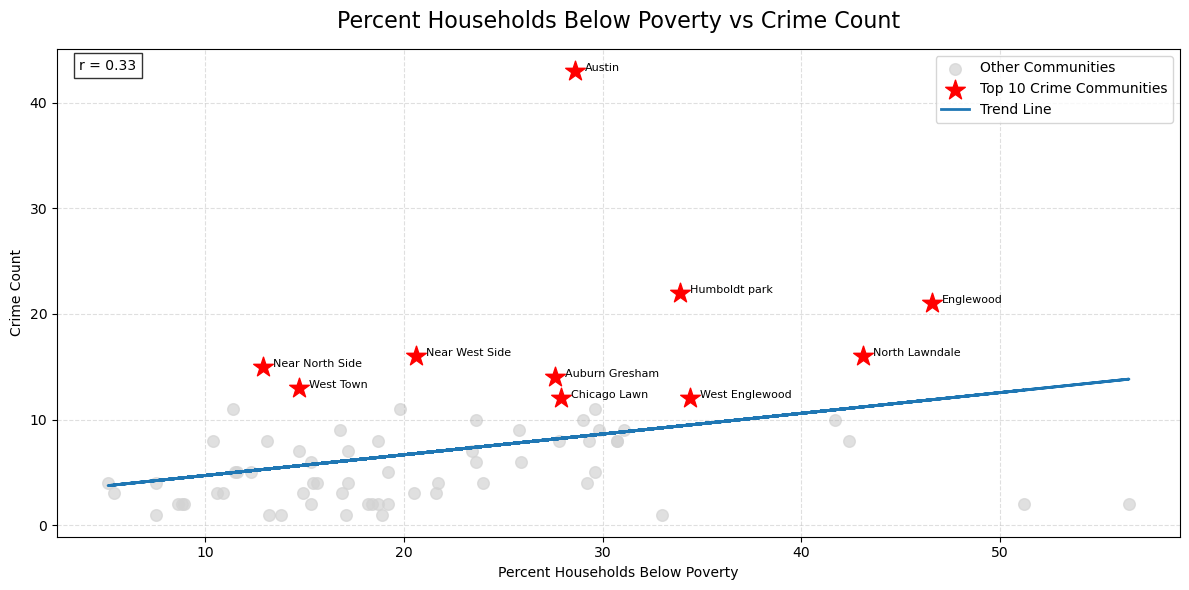

In [16]:
query = """
select 
    census.community_area_name,
    census.percent_households_below_poverty,
    count(crime.community_area_number) as Crime_Count
from chicago_crime_data as crime
join chicago_census_data as census
    on crime.community_area_number = census.community_area_number
group by census.community_area_name;
"""

# Load SQL result into a DataFrame
df = pd.read_sql_query(query, con)


# Get the top 10 communities with the highest crime count
top10 = df.nlargest(10, "Crime_Count")["COMMUNITY_AREA_NAME"]

# Split the data
regular = df[~df["COMMUNITY_AREA_NAME"].isin(top10)]
highlight = df[df["COMMUNITY_AREA_NAME"].isin(top10)]

# Scatter Plot
plt.figure(figsize=(12, 6))

# All communities
plt.scatter(
    regular["PERCENT_HOUSEHOLDS_BELOW_POVERTY"],
    regular["Crime_Count"],
    color="lightgray",
    s=70,
    alpha=0.7,
    label="Other Communities"
)

# Top 10 communities
plt.scatter(
    highlight["PERCENT_HOUSEHOLDS_BELOW_POVERTY"],
    highlight["Crime_Count"],
    color="red",
    marker="*",
    s=220,
    label="Top 10 Crime Communities"
)

# Trend line (using ALL communities)
x = df["PERCENT_HOUSEHOLDS_BELOW_POVERTY"]
y = df["Crime_Count"]

m, b = np.polyfit(x, y, 1)

plt.plot(
    x,
    m * x + b,
    linewidth=2,
    label="Trend Line"
)

plt.title("Percent Households Below Poverty vs Crime Count", fontsize=16, pad=15)
plt.xlabel("Percent Households Below Poverty")
plt.ylabel("Crime Count")

plt.grid(True, linestyle="--", alpha=0.4)

# Label only the highlighted communities
for _, row in highlight.iterrows():
    plt.text(
        row["PERCENT_HOUSEHOLDS_BELOW_POVERTY"] + 0.5,
        row["Crime_Count"],
        row["COMMUNITY_AREA_NAME"],
        fontsize=8
    )

r = df["PERCENT_HOUSEHOLDS_BELOW_POVERTY"].corr(df["Crime_Count"])

plt.text(
    0.02,
    0.98,
    f"r = {r:.2f}",
    transform=plt.gca().transAxes,
    verticalalignment="top",
    bbox=dict(facecolor="white", alpha=0.8)
)

plt.legend()

plt.tight_layout()
plt.show()

The socioeconomic indicators examined (hardship index, per capita income, and percentage of households below the poverty line) each showed only weak linear relationships with crime count (|r| ≤ 0.33). These findings suggest that no single factor strongly explains differences in crime counts across Chicago communities, indicating that crime is likely influenced by a combination of demographic, economic, and environmental factors.

### C. Crime Around Schools

Question:
- What crimes are occuring at schools?


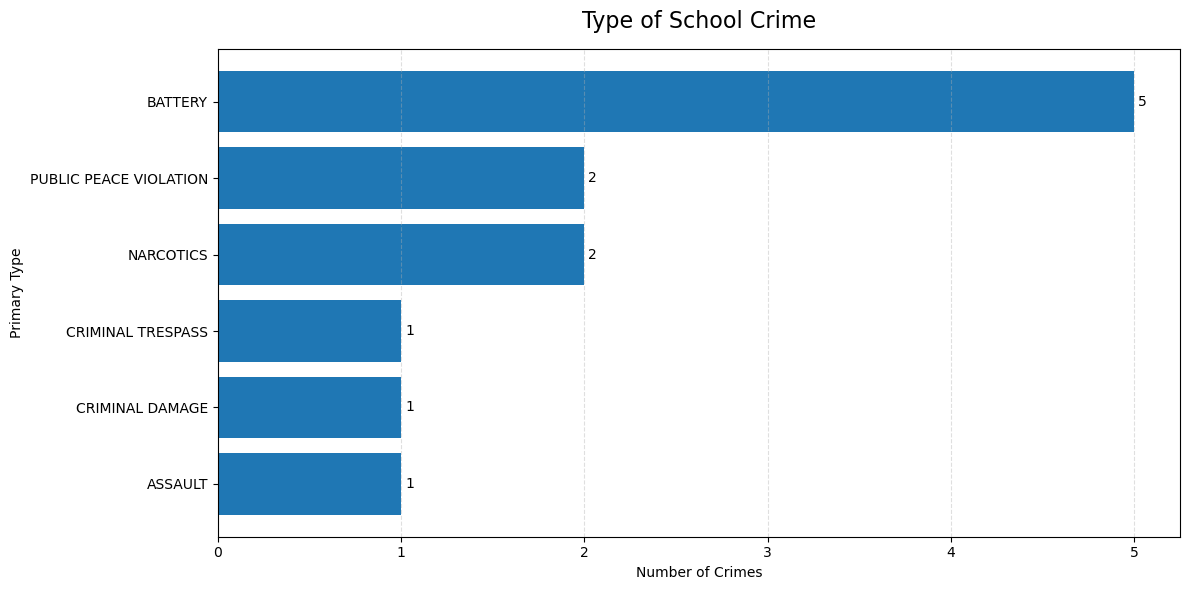

In [18]:
query = """
select primary_type, count(primary_type) as Crime_Count
from chicago_crime_data
where location_description like '%school%'
group by primary_type
order by Crime_Count desc;
"""

# Load SQL result into a DataFrame
df = pd.read_sql_query(query, con)


# Plot
plt.figure(figsize=(12, 6))

bars = plt.barh(df["PRIMARY_TYPE"], df["Crime_Count"])

plt.title("Type of School Crime",
          fontsize=16,
          pad=15)

plt.xlabel("Number of Crimes")
plt.ylabel("Primary Type")

plt.grid(axis="x", linestyle="--", alpha=0.4)

# Add the values at the end of each bar
plt.bar_label(bars, padding=3)

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [20]:
%%sql
select "Elementary, Middle, or High School", avg(safety_score)
from chicago_public_schools_data
group by "Elementary, Middle, or High School";

 * sqlite:///FinalDB.db
Done.


"Elementary, Middle, or High School",avg(safety_score)
ES,49.52038369304557
HS,49.62352941176471
MS,48.0


### D. Crimes Involving Youth

Question:
- How many crimes involve minors?
- Were kidnapping involving children common?


In [22]:
%%sql

select *
from chicago_crime_data
    where description like "%minor%";

 * sqlite:///FinalDB.db
Done.


ID,CASE_NUMBER,DATE,BLOCK,IUCR,PRIMARY_TYPE,DESCRIPTION,LOCATION_DESCRIPTION,ARREST,DOMESTIC,BEAT,DISTRICT,WARD,COMMUNITY_AREA_NUMBER,FBICODE,X_COORDINATE,Y_COORDINATE,YEAR,LATITUDE,LONGITUDE,LOCATION
3987219,HL266884,2005-03-31,024XX N CLARK ST,2210,LIQUOR LAW VIOLATION,SELL/GIVE/DEL LIQUOR TO MINOR,CONVENIENCE STORE,1,0,2333,19,43.0,7.0,22,1172680.0,1916483.0,2005,41.92626872,-87.64089934,"(41.926268719, -87.640899336)"
3266814,HK238408,2004-03-13,093XX S STONY ISLAND AVE,2230,LIQUOR LAW VIOLATION,ILLEGAL CONSUMPTION BY MINOR,ALLEY,1,0,413,4,8.0,48.0,22,1188539.0,1843379.0,2004,41.72530099,-87.58496589,"(41.72530099, -87.584965887)"


In [24]:
%%sql

    
SELECT *
FROM CHICAGO_CRIME_DATA
WHERE PRIMARY_TYPE = 'KIDNAPPING'
  AND DESCRIPTION LIKE '%CHILD%';

 * sqlite:///FinalDB.db
Done.


ID,CASE_NUMBER,DATE,BLOCK,IUCR,PRIMARY_TYPE,DESCRIPTION,LOCATION_DESCRIPTION,ARREST,DOMESTIC,BEAT,DISTRICT,WARD,COMMUNITY_AREA_NUMBER,FBICODE,X_COORDINATE,Y_COORDINATE,YEAR,LATITUDE,LONGITUDE,LOCATION
5276766,HN144152,2007-01-26,050XX W VAN BUREN ST,1792,KIDNAPPING,CHILD ABDUCTION/STRANGER,STREET,0,0,1533,15,29.0,25.0,20,1143050.0,1897546.0,2007,41.87490841,-87.75024931,"(41.874908413, -87.750249307)"


Incidents involving minors or child kidnapping represented only a very small portion of the overall crime dataset.

# Key Findings

- Austin (Community Area 25) experienced the highest number of reported crimes.
- School-related crimes were primarily Battery and Criminal Damage.
- Crimes involving minors were relatively uncommon.
- Communities with higher hardship indexes generally appeared among those with higher crime counts.

# Recommendations

- Allocate additional law enforcement resources toward high-crime communities.
- Continue monitoring school safety, particularly where Battery incidents are more common.
- Communities with higher hardship may benefit from additional economic and social support initiatives.